Pune House Rent Prediction By using Linear Regression

In [2]:
import pandas as pd
import numpy as np 


Data Loading

In [3]:
df=pd.read_csv("pune rent dataset.csv")

Data Exploring and Understanding

In [4]:
df.head(10)

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
0,Akurdi,1 BHK,318.0,Semi-Furnished,13.0,15.0,15.0,0.0,1.0,1.0,Yes,Immediate,Bachelor,25875.0,8625.0
1,Akurdi,2 BHK,757.0,Semi-Furnished,1.0,3.0,20.0,1.0,2.0,1.0,No,Immediate,Family,121575.0,40525.0
2,Akurdi,1 BHK,510.0,Fully Furnished,14.0,15.0,10.0,0.0,1.0,1.0,Yes,After 1 Month,Family,52444.0,26222.0
3,Akurdi,1 BHK,414.0,Semi-Furnished,1.0,3.0,3.0,0.0,1.0,1.0,No,Immediate,Family,51705.0,17235.0
4,Akurdi,2 BHK,954.0,Semi-Furnished,7.0,12.0,7.0,1.0,1.0,2.0,Yes,Not Sure,Family,58014.0,58014.0
5,Akurdi,1 BHK,488.0,Semi-Furnished,5.0,6.0,1.0,0.0,1.0,2.0,Yes,Immediate,Family,38976.0,19488.0
6,Akurdi,2 BHK,914.0,Unfurnished,3.0,4.0,6.0,1.0,2.0,1.0,Yes,After 1 Month,Family,124410.0,41470.0
7,Akurdi,1 BHK,453.0,Semi-Furnished,2.0,12.0,9.0,0.0,1.0,0.0,Yes,Immediate,Both,27434.0,13717.0
8,Akurdi,2 BHK,791.0,Fully Furnished,0.0,3.0,18.0,1.0,2.0,1.0,No,Immediate,Family,66716.0,33358.0
9,Akurdi,2 BHK,985.0,Semi-Furnished,15.0,15.0,10.0,1.0,2.0,1.0,Yes,Immediate,Family,116340.0,58170.0


In [5]:
df.shape

(20102, 15)

In [6]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20102 entries, 0 to 20101
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Locality               20101 non-null  object 
 1   BHK                    20100 non-null  object 
 2   Area_sqft              20100 non-null  float64
 3   Furnishing             20100 non-null  object 
 4   Floor_Number           20100 non-null  float64
 5   Total_Building_Floors  20100 non-null  float64
 6   Age_Years              20100 non-null  float64
 7   Balconies              20100 non-null  float64
 8   Bathrooms              20100 non-null  float64
 9   Parking                20100 non-null  float64
 10  Lift                   20100 non-null  object 
 11  Availability           20100 non-null  object 
 12  Tenant_Type            20100 non-null  object 
 13  Security_Deposit       20100 non-null  float64
 14  Rent_INR               20100 non-null  float64
dtypes:

In [7]:
df.tail(10)

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
20092,Yerawada,2 BHK,996.0,Semi-Furnished,10.0,10.0,21.0,1.0,2.0,0.0,Yes,Immediate,Both,82278.0,41139.0
20093,Yerawada,2 BHK,722.0,Unfurnished,4.0,12.0,6.0,0.0,2.0,1.0,Yes,Not Sure,Family,50422.0,25211.0
20094,Yerawada,2 BHK,809.0,Unfurnished,6.0,8.0,8.0,1.0,2.0,1.0,Yes,Not Sure,Bachelor,40106.0,40106.0
20095,Yerawada,3 BHK,1346.0,Semi-Furnished,3.0,3.0,5.0,1.0,2.0,2.0,No,Immediate,Family,155830.0,77915.0
20096,Yerawada,2 BHK,842.0,Semi-Furnished,2.0,5.0,0.0,1.0,2.0,1.0,Yes,After 2 Months,Family,94766.0,47383.0
20097,Yerawada,1 BHK,369.0,Unfurnished,1.0,4.0,28.0,0.0,1.0,1.0,Yes,Immediate,Family,16320.0,8160.0
20098,Yerawada,3 BHK,1290.0,Fully Furnished,0.0,10.0,18.0,1.0,3.0,1.0,Yes,After 1 Month,Bachelor,210208.0,105104.0
20099,Yerawada,2 BHK,785.0,Semi-Furnished,3.0,3.0,10.0,0.0,2.0,1.0,No,Immediate,Family,32136.0,32136.0
20100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning and Handling Missing and Null Data 

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull()

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20097,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
20098,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
20099,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
20100,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [10]:
df.isnull().sum()

Locality                 1
BHK                      2
Area_sqft                2
Furnishing               2
Floor_Number             2
Total_Building_Floors    2
Age_Years                2
Balconies                2
Bathrooms                2
Parking                  2
Lift                     2
Availability             2
Tenant_Type              2
Security_Deposit         2
Rent_INR                 2
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

Locality                 0
BHK                      0
Area_sqft                0
Furnishing               0
Floor_Number             0
Total_Building_Floors    0
Age_Years                0
Balconies                0
Bathrooms                0
Parking                  0
Lift                     0
Availability             0
Tenant_Type              0
Security_Deposit         0
Rent_INR                 0
dtype: int64

In [13]:
df.describe()


,Area_sqft,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Security_Deposit,Rent_INR
count,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000
mean,686.691294,3.899353,7.872438,10.326070,0.688408,1.511045,1.007612,64847.448308,32469.346965
std,290.401730,3.391729,3.929100,6.887303,0.714874,0.576612,0.547729,53748.545943,23595.271360
min,200.000000,0.000000,3.000000,0.000000,0.000000,1.000000,0.000000,3989.000000,3045.000000
25%,429.000000,1.000000,4.000000,5.000000,0.000000,1.000000,1.000000,29887.500000,15961.500000
50%,676.000000,3.000000,6.000000,10.000000,1.000000,1.000000,1.000000,49107.000000,26041.500000
75%,885.000000,6.000000,12.000000,15.000000,1.000000,2.000000,1.000000,83741.500000,42082.000000
max,1842.000000,15.000000,15.000000,44.000000,3.000000,3.000000,2.000000,773316.000000,257772.000000


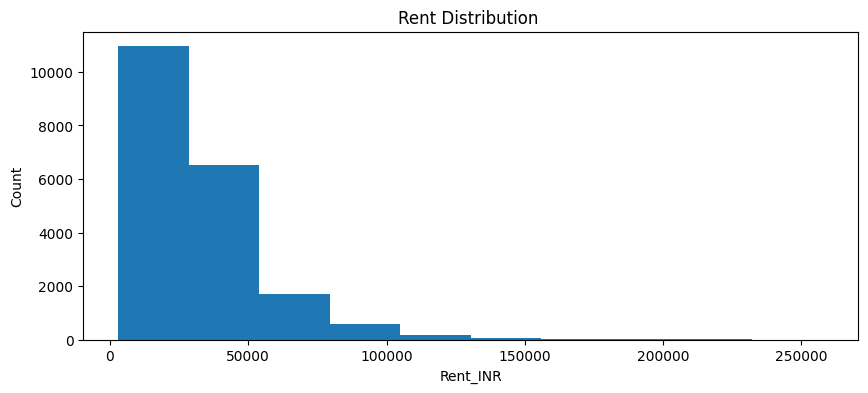

In [14]:
import matplotlib.pyplot as plt

# Histogram of target
plt.figure(figsize=(10,4))
plt.hist(df['Rent_INR'], bins=10)
plt.title('Rent Distribution ')
plt.xlabel('Rent_INR')
plt.ylabel('Count')
plt.show()

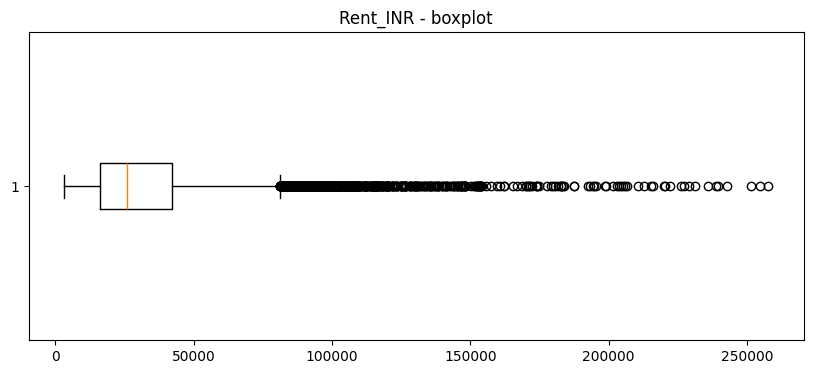

In [15]:
plt.figure(figsize=(10,4))
plt.boxplot(df['Rent_INR'], vert=False)
plt.title('Rent_INR - boxplot')
plt.show()

In [16]:
# Handling Outlier by IQR Method 



Q1=df['Rent_INR'].quantile(0.25)
Q3=df['Rent_INR'].quantile(0.75)
print(Q1  ,   Q3)


IQR=Q3-Q1
print(IQR)

lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

15961.5 42082.0
26120.5


(np.float64(-23219.25), np.float64(81262.75))

In [17]:
outliers = df[(df['Rent_INR'] < lower_limit) | (df['Rent_INR'] > upper_limit)]

outliers.shape

(849, 15)

In [18]:
Rent  = df[(df['Rent_INR'] > lower_limit) & (df['Rent_INR'] < upper_limit)]
Rent 

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
0,Akurdi,1 BHK,318.0,Semi-Furnished,13.0,15.0,15.0,0.0,1.0,1.0,Yes,Immediate,Bachelor,25875.0,8625.0
1,Akurdi,2 BHK,757.0,Semi-Furnished,1.0,3.0,20.0,1.0,2.0,1.0,No,Immediate,Family,121575.0,40525.0
2,Akurdi,1 BHK,510.0,Fully Furnished,14.0,15.0,10.0,0.0,1.0,1.0,Yes,After 1 Month,Family,52444.0,26222.0
3,Akurdi,1 BHK,414.0,Semi-Furnished,1.0,3.0,3.0,0.0,1.0,1.0,No,Immediate,Family,51705.0,17235.0
4,Akurdi,2 BHK,954.0,Semi-Furnished,7.0,12.0,7.0,1.0,1.0,2.0,Yes,Not Sure,Family,58014.0,58014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20094,Yerawada,2 BHK,809.0,Unfurnished,6.0,8.0,8.0,1.0,2.0,1.0,Yes,Not Sure,Bachelor,40106.0,40106.0
20095,Yerawada,3 BHK,1346.0,Semi-Furnished,3.0,3.0,5.0,1.0,2.0,2.0,No,Immediate,Family,155830.0,77915.0
20096,Yerawada,2 BHK,842.0,Semi-Furnished,2.0,5.0,0.0,1.0,2.0,1.0,Yes,After 2 Months,Family,94766.0,47383.0
20097,Yerawada,1 BHK,369.0,Unfurnished,1.0,4.0,28.0,0.0,1.0,1.0,Yes,Immediate,Family,16320.0,8160.0


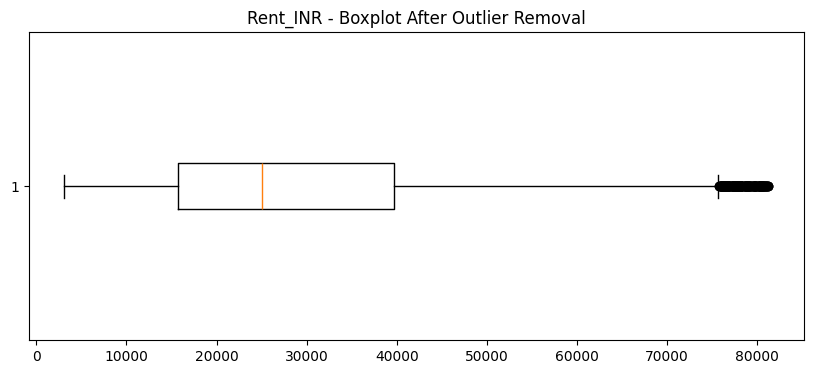

In [19]:
plt.figure(figsize=(10,4))
plt.boxplot(Rent['Rent_INR'], vert=False)
plt.title('Rent_INR - Boxplot After Outlier Removal')
plt.show()

In [20]:
df.head()

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
0,Akurdi,1 BHK,318.0,Semi-Furnished,13.0,15.0,15.0,0.0,1.0,1.0,Yes,Immediate,Bachelor,25875.0,8625.0
1,Akurdi,2 BHK,757.0,Semi-Furnished,1.0,3.0,20.0,1.0,2.0,1.0,No,Immediate,Family,121575.0,40525.0
2,Akurdi,1 BHK,510.0,Fully Furnished,14.0,15.0,10.0,0.0,1.0,1.0,Yes,After 1 Month,Family,52444.0,26222.0
3,Akurdi,1 BHK,414.0,Semi-Furnished,1.0,3.0,3.0,0.0,1.0,1.0,No,Immediate,Family,51705.0,17235.0
4,Akurdi,2 BHK,954.0,Semi-Furnished,7.0,12.0,7.0,1.0,1.0,2.0,Yes,Not Sure,Family,58014.0,58014.0


In [21]:

print("\n Tenant  counts:")
print(df['Tenant_Type'].value_counts()) # gives total no of counts aas per category
print("BHK  counts:")
print(df['BHK'].value_counts()) # total number
print("\nFurnishing counts:")
print(df['Furnishing'].value_counts())


 Tenant  counts:
Tenant_Type
Family      12066
Bachelor     5137
Both         2897
Name: count, dtype: int64
BHK  counts:
BHK
1 BHK    9098
2 BHK    8074
3 BHK    2928
Name: count, dtype: int64

Furnishing counts:
Furnishing
Semi-Furnished     9998
Unfurnished        6152
Fully Furnished    3950
Name: count, dtype: int64


In [22]:
features = [
    'Area_sqft',
    'Floor_Number',
    'Total_Building_Floors',
    'Age_Years',
    'Balconies', 
    'Bathrooms',
    'Parking',
    'Security_Deposit',
    'Rent_INR',
    'Locality',              # categorical
    'BHK',                    # categorical
    'Furnishing',            # categorical
    'Availability',           # categorical
    'Tenant_Type',          # categorical
]

#Split 

X = df.drop('Rent_INR',axis=1)
y = df['Rent_INR'].copy()  # target Series


In [23]:
#training the data 

from sklearn.model_selection import train_test_split

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
print("Train rows:", X_train.shape[0])

print("Test rows:", X_test.shape[0])

Train rows: 16080
Test rows: 4020


In [25]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ['Locality','BHK','Furnishing','Availability', 'Tenant_Type']
num_cols = [
     'Area_sqft',
    'Floor_Number',
    'Total_Building_Floors',
    'Age_Years',
    'Balconies', 
    'Bathrooms',
    'Parking',
    'Security_Deposit'
]

# Build ColumnTransformer for our model
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),                 # scale numerics columns 
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)  # one-hot (drop one to avoid dummy trap)
    ],
    remainder='drop'  # drop any other columns, if present
)


In [26]:
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_train_transformed.shape

(16080, 217)

In [27]:
from sklearn.linear_model import LinearRegression
#create pipeline on training data 
model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('linear_reg', LinearRegression())
])

# Fit the pipeline on training data
model_pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('linear_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test set
y_pred = model_pipeline.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE:{mse:.2f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2: {r2:.3f}") 

MAE: 5651.926
MSE:70214278.41
RMSE: 8379.396
R^2: 0.874


In [29]:
df.head(5)

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
0,Akurdi,1 BHK,318.0,Semi-Furnished,13.0,15.0,15.0,0.0,1.0,1.0,Yes,Immediate,Bachelor,25875.0,8625.0
1,Akurdi,2 BHK,757.0,Semi-Furnished,1.0,3.0,20.0,1.0,2.0,1.0,No,Immediate,Family,121575.0,40525.0
2,Akurdi,1 BHK,510.0,Fully Furnished,14.0,15.0,10.0,0.0,1.0,1.0,Yes,After 1 Month,Family,52444.0,26222.0
3,Akurdi,1 BHK,414.0,Semi-Furnished,1.0,3.0,3.0,0.0,1.0,1.0,No,Immediate,Family,51705.0,17235.0
4,Akurdi,2 BHK,954.0,Semi-Furnished,7.0,12.0,7.0,1.0,1.0,2.0,Yes,Not Sure,Family,58014.0,58014.0


In [30]:
df.tail()

,Locality,BHK,Area_sqft,Furnishing,Floor_Number,Total_Building_Floors,Age_Years,Balconies,Bathrooms,Parking,Lift,Availability,Tenant_Type,Security_Deposit,Rent_INR
20095,Yerawada,3 BHK,1346.0,Semi-Furnished,3.0,3.0,5.0,1.0,2.0,2.0,No,Immediate,Family,155830.0,77915.0
20096,Yerawada,2 BHK,842.0,Semi-Furnished,2.0,5.0,0.0,1.0,2.0,1.0,Yes,After 2 Months,Family,94766.0,47383.0
20097,Yerawada,1 BHK,369.0,Unfurnished,1.0,4.0,28.0,0.0,1.0,1.0,Yes,Immediate,Family,16320.0,8160.0
20098,Yerawada,3 BHK,1290.0,Fully Furnished,0.0,10.0,18.0,1.0,3.0,1.0,Yes,After 1 Month,Bachelor,210208.0,105104.0
20099,Yerawada,2 BHK,785.0,Semi-Furnished,3.0,3.0,10.0,0.0,2.0,1.0,No,Immediate,Family,32136.0,32136.0


In [31]:
import pandas as pd
import joblib
new_rent = pd.DataFrame({
    'Area_sqft': [1346.0],
    'Floor_Number':[3.0],
    'Total_Building_Floors':[3.0],
    'Age_Years':[5.0],
    'Balconies':[1.0], 
    'Bathrooms':[2.0],
    'Parking':[2.0],
    'Security_Deposit':[155830.0],
    'Locality':['Yerawada'],
    'BHK':['3 BHK'],
    'Furnishing':['Semi-Furnished'],
    'Availability':['Immediate'],
    'Tenant_Type':['Family']
})

predicted_rent = model_pipeline.predict(new_rent)

print(f"Predicted Rent: {predicted_rent[0]:.2f} INR")



Predicted Rent: 74640.78 INR


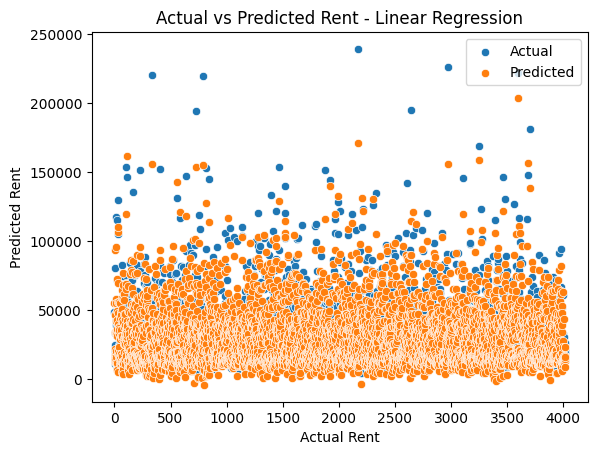

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=range(len(y_test)), y=y_test, label="Actual")
sns.scatterplot(x=range(len(y_pred)), y=y_pred, label="Predicted")
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent - Linear Regression")
plt.show()

Conclusion 

- Developed a house rent prediction model for Pune using Linear Regression.
- Performed data cleaning, EDA, and feature engineering to improve prediction accuracy.
- Evaluated the model using MAE, RMSE, and achieved an R² score of 0.874 with accuracy of 87.4%.